PREDIKSI ALERT GEMPA DENGAN TIGA MODEL MACHINE LEARNING

Disusun Oleh:
Farsya Runa Supriyatna (231011403757)
Testarina Tatiana Hermansyah (231011400475)

In [10]:
import pandas as pd                     # Untuk manipulasi data (baca file CSV, buat dataframe)
import numpy as np                      # Untuk operasi numerik dan array
from sklearn.model_selection import train_test_split  # Untuk membagi data menjadi data latih & uji
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Untuk normalisasi & encoding label
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Untuk evaluasi model
import matplotlib.pyplot as plt          # Untuk visualisasi grafik
import seaborn as sns                    # Untuk visualisasi data yang lebih estetis
from sklearn.neural_network import MLPClassifier  # Model Artificial Neural Network
from sklearn.ensemble import RandomForestClassifier  # Model Random Forest
from sklearn.svm import SVC              # Model Support Vector Machine (SVM)

In [11]:
# MEMUAT DATASET
file_path = 'earthquake_alert_balanced_dataset.csv'   # Lokasi file dataset
df = pd.read_csv(file_path, delimiter=';')            # Membaca dataset CSV dengan pemisah (;)

# Menampilkan informasi dasar dataset
print("\n== DATASET ==")
print(df.head())                                     # Menampilkan 5 baris pertama
print("\nJumlah baris & kolom:", df.shape)            # Menampilkan jumlah baris dan kolom
print("Cek missing values:\n", df.isnull().sum())     # Mengecek apakah ada data kosong (null)

#PRA-PROSES DATA
le = LabelEncoder()                                   # Inisialisasi encoder untuk mengubah label teks → angka
df['alert_encoded'] = le.fit_transform(df['alert'])   # Mengonversi kolom ‘alert’ menjadi bentuk numerik

# Menentukan fitur yang akan digunakan untuk prediksi
features = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']
X = df[features]                                      # Variabel independen (fitur input)
y = df['alert_encoded']                               # Variabel dependen (label target)

# Normalisasi data agar semua fitur berada dalam skala seragam
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)                    # Fit & transform data menjadi bentuk terstandarisasi

# Membagi data menjadi data latih (80%) dan uji (20%)
# stratify=y → memastikan proporsi kelas tetap seimbang antara train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Menampilkan jumlah data setelah dibagi
print("\nJumlah data latih:", X_train.shape[0])
print("Jumlah data uji   :", X_test.shape[0])


== DATASET ==
   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green

Jumlah baris & kolom: (1300, 6)
Cek missing values:
 magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

Jumlah data latih: 1040
Jumlah data uji   : 260


 MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN) 

Akurasi Model ANN: 89.23%

Laporan Klasifikasi ANN:
              precision    recall  f1-score   support

       green       0.90      0.85      0.87        65
      orange       0.88      0.91      0.89        65
         red       0.95      0.97      0.96        65
      yellow       0.83      0.85      0.84        65

    accuracy                           0.89       260
   macro avg       0.89      0.89      0.89       260
weighted avg       0.89      0.89      0.89       260



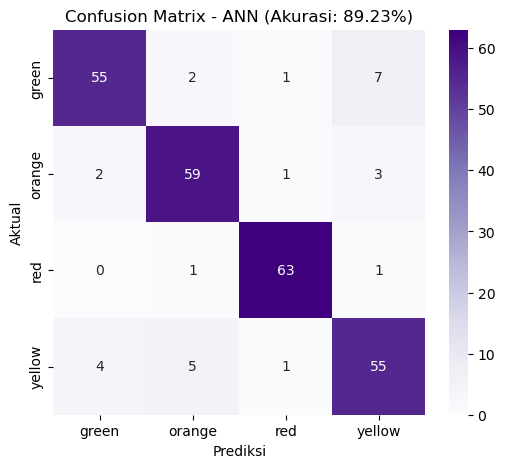

In [12]:
# MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN)
print(" MODEL 1: ARTIFICIAL NEURAL NETWORK (ANN) ")

# Membuat model ANN dengan 3 hidden layer (100, 50, 20 neuron)
ann_model = MLPClassifier(
    hidden_layer_sizes=(100, 50, 20),  # Struktur lapisan tersembunyi
    activation='relu',                 # Fungsi aktivasi ReLU
    solver='adam',                     # Optimizer Adam
    max_iter=1000,                      # Maksimum iterasi training
    random_state=42,                   # Seed agar hasil konsisten
    verbose=False                      # Tidak menampilkan log selama training
)

# Melatih model menggunakan data latih
ann_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred_ann = ann_model.predict(X_test)

# Menghitung akurasi prediksi
acc_ann = accuracy_score(y_test, y_pred_ann)
print(f"\nAkurasi Model ANN: {acc_ann*100:.2f}%")

# Menampilkan laporan klasifikasi (precision, recall, f1-score)
print("\nLaporan Klasifikasi ANN:")
print(classification_report(y_test, y_pred_ann, target_names=le.classes_))

# Membuat confusion matrix untuk melihat hasil prediksi per kelas
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - ANN (Akurasi: {acc_ann*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()



=== MODEL 2: RANDOM FOREST CLASSIFIER ===

Akurasi Model Random Forest: 92.31%

Laporan Klasifikasi Random Forest:
              precision    recall  f1-score   support

       green       0.98      0.85      0.91        65
      orange       0.94      0.95      0.95        65
         red       0.98      0.97      0.98        65
      yellow       0.81      0.92      0.86        65

    accuracy                           0.92       260
   macro avg       0.93      0.92      0.92       260
weighted avg       0.93      0.92      0.92       260



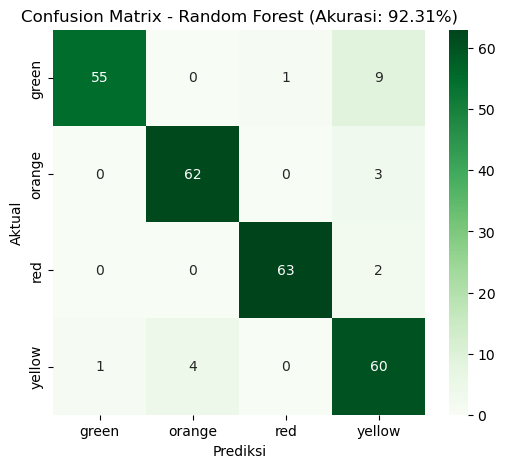

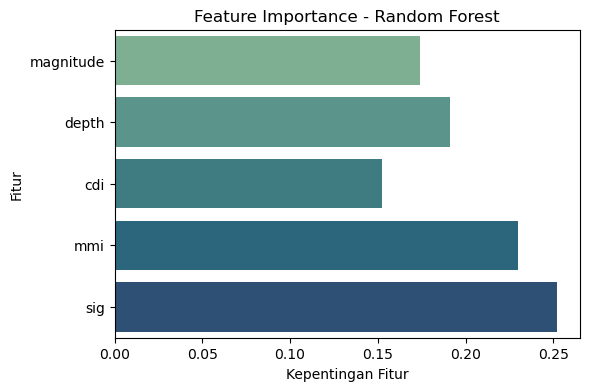

In [ ]:
# MODEL 2: RANDOM FOREST CLASSIFIER
print("\n=== MODEL 2: RANDOM FOREST CLASSIFIER ===")

# Membuat model Random Forest dengan 100 pohon (decision trees)
rf_model = RandomForestClassifier(
    n_estimators=100,   # Jumlah pohon dalam hutan
    random_state=42,    # Seed agar hasil konsisten
    criterion='gini'    # Kriteria pemisahan (bisa juga 'entropy')
)

# Melatih model
rf_model.fit(X_train, y_train)

# Prediksi data uji
y_pred_rf = rf_model.predict(X_test)

# Menghitung akurasi
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAkurasi Model Random Forest: {acc_rf*100:.2f}%")

# Menampilkan metrik evaluasi
print("\nLaporan Klasifikasi Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Membuat confusion matrix perbandingan antara hasil prediksi model dengan label sebenarnya.
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - Random Forest (Akurasi: {acc_rf*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# VISUALISASI PENTINGNYA FITUR PADA RANDOM FOREST
importances = rf_model.feature_importances_           # Nilai penting tiap fitur
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features, hue=features, palette='crest', legend=False)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Kepentingan Fitur")
plt.ylabel("Fitur")
plt.show()


=== MODEL 3: SUPPORT VECTOR MACHINE (SVM) ===

Akurasi Model SVM: 81.15%

Laporan Klasifikasi SVM:
              precision    recall  f1-score   support

       green       0.98      0.78      0.87        65
      orange       0.79      0.69      0.74        65
         red       0.74      0.98      0.84        65
      yellow       0.80      0.78      0.79        65

    accuracy                           0.81       260
   macro avg       0.83      0.81      0.81       260
weighted avg       0.83      0.81      0.81       260



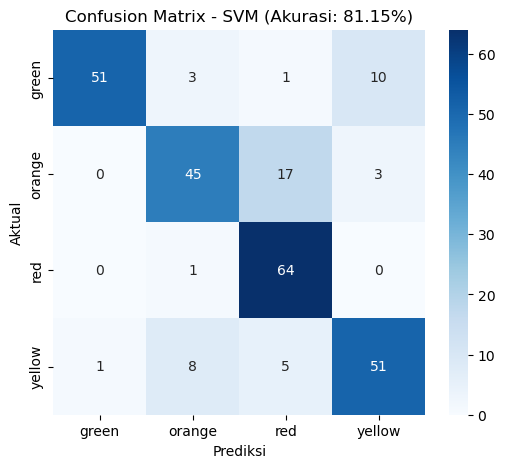


Contoh Prediksi Baru (SVM): yellow


In [14]:
# MODEL 3: SUPPORT VECTOR MACHINE (SVM)
print("\n=== MODEL 3: SUPPORT VECTOR MACHINE (SVM) ===")

# Membuat model SVM dengan kernel RBF (radial basis function)
svm_model = SVC(kernel='rbf', C=2, gamma='scale', random_state=42)

# Melatih model
svm_model.fit(X_train, y_train)

# Prediksi data uji
y_pred_svm = svm_model.predict(X_test)

# Hitung akurasi
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nAkurasi Model SVM: {acc_svm*100:.2f}%")

# Laporan klasifikasi
print("\nLaporan Klasifikasi SVM:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - SVM (Akurasi: {acc_svm*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# PREDIKSI BARU MENGGUNAKAN MODEL SVM
# Contoh input baru: magnitude, depth, cdi, mmi, sig
new_data = pd.DataFrame([[6.8, 20.0, 8.0, 7.0, -101.0]], columns=features)
new_data_scaled = scaler.transform(new_data)          # Normalisasi input baru
pred_label = le.inverse_transform(svm_model.predict(new_data_scaled))  # Prediksi label asli
print(f"\nContoh Prediksi Baru (SVM): {pred_label[0]}")

=== PERBANDINGAN AKURASI MODEL ===
ANN (Artificial Neural Network): 89.23%
RF  (Random Forest)             : 92.31%
SVM (Support Vector Machine)    : 81.15%


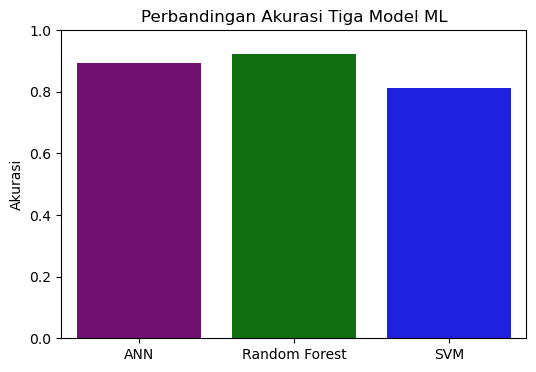


 Program selesai dijalankan.


In [15]:
# PERBANDINGAN HASIL AKHIR SEMUA MODEL
print("=== PERBANDINGAN AKURASI MODEL ===")
print(f"ANN (Artificial Neural Network): {acc_ann*100:.2f}%")
print(f"RF  (Random Forest)             : {acc_rf*100:.2f}%")
print(f"SVM (Support Vector Machine)    : {acc_svm*100:.2f}%")

# Menampilkan grafik perbandingan akurasi
plt.figure(figsize=(6,4))
models = ['ANN', 'Random Forest', 'SVM']
accuracies = [acc_ann, acc_rf, acc_svm]
sns.barplot(x=models, y=accuracies, hue=models, palette=['purple','green','blue'], legend=False)
plt.title("Perbandingan Akurasi Tiga Model ML")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()

print("\n Program selesai dijalankan.")